# Optical Proximity Correction (OPC) Demo — Week 12

This notebook walks through the last stage of the pipeline this project has been building
week-by-week alongside Goodman's *Introduction to Fourier Optics*:

```
Mask pattern → Angular spectrum propagation → Lens (NA cutoff) → Aerial image → Threshold →
Printed feature → OPC correction
```

**The story:**
1. Start from a target mask (what we *want* printed).
2. Forward-model it through the diffraction-limited imaging system built in `lens.py`/`imaging.py`
   — the printed feature comes out measurably distorted (nonzero edge placement error, EPE).
3. Apply `physics/opc.py`'s iterative edge-bias correction: pre-distort the mask edges opposite
   the measured print error until the *print*, not the mask, matches the target.
4. Quantify the improvement.

Physically, this is proximity effect correction: the printed position of a mask edge depends on
the imaging system's own band-limited (diffraction) response, not just that edge in isolation.
Goodman Sec. 6.6.1 explains *why* a finite-NA system can't reproduce a mask exactly; OPC is the
lithography-engineering answer to that limitation, not a Goodman equation itself — see
`physics/opc.py`'s module docstring for the full derivation and the reasoning behind every design
choice below.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Flat (non-src) repo layout: physics/*.py and plotting/*.py import each
# other flatly (e.g. lens.py does `from masks import make_grid`), so both
# directories need to be on sys.path individually, not just the repo root
# -- same convention scripts/generate_*.py already uses (see e.g.
# scripts/generate_aberration_comparison.py), computed relatively here
# instead of hardcoded so the notebook runs from any checkout.
NOTEBOOK_DIR = Path(os.getcwd()).resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "physics"))
sys.path.insert(0, str(PROJECT_ROOT / "plotting"))

from grid import Grid1D
from masks import single_line
from constants import WAVELENGTH, NA_DEFAULT
from imaging import incoherent_aerial_image, apply_threshold, edge_placement_error
from opc import edge_bias_opc
from core import TARGET_COLOR, MASK_COLOR, IMAGE_COLOR, _style_ax

ASSETS_DIR = PROJECT_ROOT / "assets"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"WAVELENGTH (i-line) = {WAVELENGTH} um, NA_DEFAULT = {NA_DEFAULT}")

PROJECT_ROOT = /Users/sohamdamle/Documents/fourier_optics_sim
WAVELENGTH (i-line) = 0.365 um, NA_DEFAULT = 0.5


## 1. The target mask

A single isolated line, 1.0 µm wide, on a 200 µm field sampled at 4096 points -- the same grid
used throughout `tests/test_imaging.py`'s hand-verified cases, so every number below is
independently checkable against that module's docstrings.

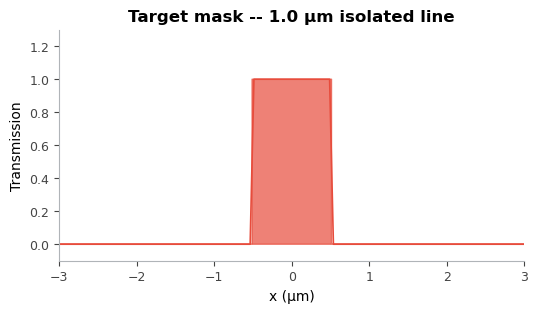

In [2]:
L, N = 200.0, 4096
grid = Grid1D(L=L, N=N)

wavelength = WAVELENGTH   # 0.365 um, i-line
NA = NA_DEFAULT           # 0.5
threshold = 0.3

target = single_line(grid.x, width=1.0, center=0.0)

fig, ax = plt.subplots(figsize=(6, 3))
ax.fill_between(grid.x, target, color=TARGET_COLOR, alpha=0.7, step="mid")
ax.plot(grid.x, target, color=TARGET_COLOR, lw=1.2)
ax.set_xlim(-3, 3)
ax.set_ylim(-0.1, 1.3)
ax.set_xlabel("x (µm)")
ax.set_ylabel("Transmission")
ax.set_title("Target mask -- 1.0 µm isolated line", fontweight="bold")
_style_ax(ax)
plt.show()

## 2. Naive forward model: the printed feature is distorted

Run the target mask, unmodified, through the same incoherent imaging chain the Results page's
"Printed Feature" panel uses (`imaging.incoherent_aerial_image` -> `imaging.apply_threshold`),
then measure per-edge EPE against the target (`imaging.edge_placement_error`). This is exactly
`physics/opc.py`'s own iteration-0 case -- no correction applied yet.

target edges:          [-0.51269531  0.51269531] um
naive printed edges:    [-0.56152344  0.56152344] um
naive EPE (per edge):   [-0.04882812  0.04882812] um
naive max |EPE|:        0.0488 um


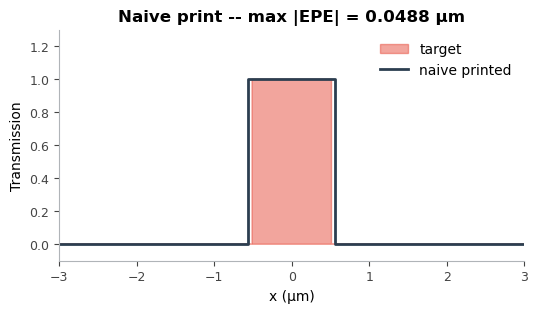

In [3]:
naive_intensity, _, _ = incoherent_aerial_image(target, grid, wavelength=wavelength, NA=NA)
naive_printed = apply_threshold(naive_intensity, threshold=threshold)
naive_epe, target_edges, naive_printed_edges = edge_placement_error(target, naive_printed, grid.x)

print(f"target edges:          {target_edges} um")
print(f"naive printed edges:    {naive_printed_edges} um")
print(f"naive EPE (per edge):   {naive_epe} um")
print(f"naive max |EPE|:        {np.max(np.abs(naive_epe)):.4f} um")

fig, ax = plt.subplots(figsize=(6, 3))
ax.fill_between(grid.x, target, color=TARGET_COLOR, alpha=0.5, step="mid", label="target")
ax.plot(grid.x, naive_printed, color=MASK_COLOR, lw=2, drawstyle="steps-mid", label="naive printed")
ax.set_xlim(-3, 3)
ax.set_ylim(-0.1, 1.3)
ax.set_xlabel("x (µm)")
ax.set_ylabel("Transmission")
ax.set_title(f"Naive print -- max |EPE| = {np.max(np.abs(naive_epe)):.4f} µm", fontweight="bold")
ax.legend(loc="upper right", frameon=False)
_style_ax(ax)
plt.show()

The printed line is visibly wider than the target: the hard-edged pupil's diffraction response
(and the resist threshold model on top of it) shifts both edges outward. This is the "proximity
effect" OPC exists to compensate for.

## 3. Apply edge-bias OPC

`physics/opc.py`'s `edge_bias_opc` runs the same forward model repeatedly, biasing each mask edge
opposite its measured EPE (damped by `gain`) until every edge's |EPE| < `convergence_tol` or
`max_iterations` is hit. Parameters below match this project's defaults
(`backend/schemas.py`'s `OpcRequest`).

In [4]:
result = edge_bias_opc(
    target, grid,
    wavelength=wavelength, NA=NA, coherence="Incoherent", threshold=threshold,
    gain=0.5, convergence_tol=0.01, max_iterations=20,
)

print(f"converged:    {result['converged']}")
print(f"n_iterations: {result['n_iterations']}")
print()
print(f"{'iteration':>9} | {'max |EPE| (um)':>15} | {'mean |EPE| (um)':>16}")
print("-" * 48)
for h in result["history"]:
    print(f"{h['iteration']:>9} | {h['max_abs_epe']:>15.4f} | {h['mean_abs_epe']:>16.4f}")

converged:    True
n_iterations: 3

iteration |  max |EPE| (um) |  mean |EPE| (um)
------------------------------------------------
        0 |          0.0488 |           0.0488
        1 |          0.0488 |           0.0244
        2 |          0.0000 |           0.0000


## 4. Corrected mask and printed feature: quantified improvement

`corrected_mask` has its edges biased inward relative to `target` (visible in the left panel
below) -- forward-modeling *that* mask instead of the naive one is what brings the print back
onto the target.

corrected printed edges: [-0.51269531  0.51269531] um
corrected EPE (per edge): [0. 0.] um
naive max |EPE|:      0.0488 um
corrected max |EPE|:  0.0000 um
improvement:          100.0%


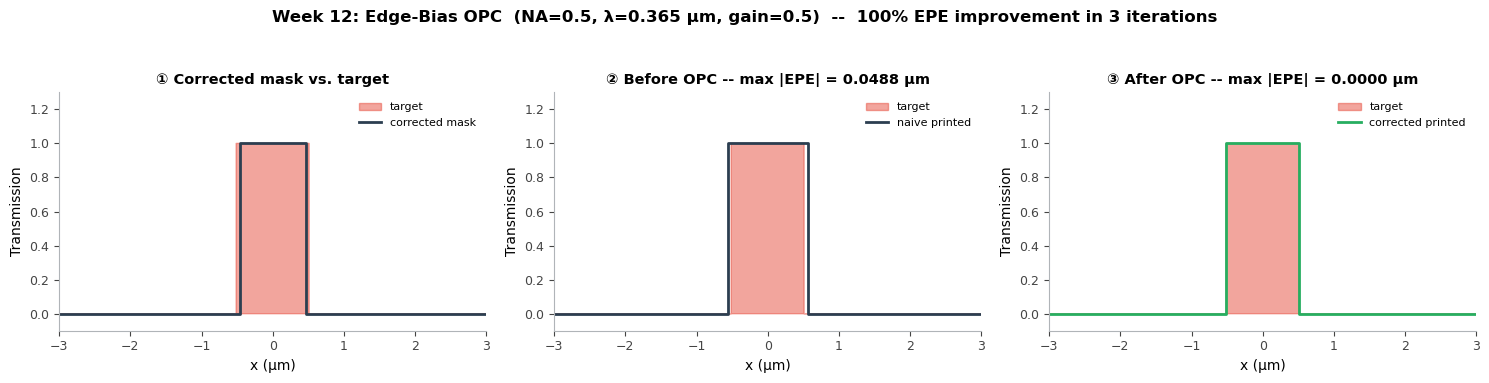

In [5]:
corrected_mask = result["corrected_mask"]
corrected_printed = result["corrected_printed"]
corrected_epe, _, corrected_printed_edges = edge_placement_error(target, corrected_printed, grid.x)

naive_max_epe = np.max(np.abs(naive_epe))
corrected_max_epe = np.max(np.abs(corrected_epe))
improvement_pct = 100.0 * (1.0 - corrected_max_epe / naive_max_epe)

print(f"corrected printed edges: {corrected_printed_edges} um")
print(f"corrected EPE (per edge): {corrected_epe} um")
print(f"naive max |EPE|:      {naive_max_epe:.4f} um")
print(f"corrected max |EPE|:  {corrected_max_epe:.4f} um")
print(f"improvement:          {improvement_pct:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

ax0 = axes[0]
ax0.fill_between(grid.x, target, color=TARGET_COLOR, alpha=0.5, step="mid", label="target")
ax0.plot(grid.x, corrected_mask, color=MASK_COLOR, lw=2, drawstyle="steps-mid", label="corrected mask")
ax0.set_title("① Corrected mask vs. target", fontweight="bold", fontsize=10.5)

ax1 = axes[1]
ax1.fill_between(grid.x, target, color=TARGET_COLOR, alpha=0.5, step="mid", label="target")
ax1.plot(grid.x, naive_printed, color=MASK_COLOR, lw=2, drawstyle="steps-mid", label="naive printed")
ax1.set_title(f"② Before OPC -- max |EPE| = {naive_max_epe:.4f} µm", fontweight="bold", fontsize=10.5)

ax2 = axes[2]
ax2.fill_between(grid.x, target, color=TARGET_COLOR, alpha=0.5, step="mid", label="target")
ax2.plot(grid.x, corrected_printed, color=IMAGE_COLOR, lw=2, drawstyle="steps-mid", label="corrected printed")
ax2.set_title(f"③ After OPC -- max |EPE| = {corrected_max_epe:.4f} µm", fontweight="bold", fontsize=10.5)

for ax in axes:
    ax.set_xlim(-3, 3)
    ax.set_ylim(-0.1, 1.3)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("Transmission")
    ax.legend(loc="upper right", frameon=False, fontsize=8)
    _style_ax(ax)

fig.suptitle(
    f"Week 12: Edge-Bias OPC  (NA={NA}, λ={wavelength} µm, gain=0.5)  --  "
    f"{improvement_pct:.0f}% EPE improvement in {result['n_iterations']} iterations",
    fontsize=12, fontweight="bold", y=1.05,
)
fig.tight_layout()
fig.savefig(ASSETS_DIR / "week12_opc_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Convergence history

EPE (both max and mean, across all edges) shrinks monotonically iteration-to-iteration for this
damped (`gain=0.5`) case -- no oscillation, no overshoot past the target.

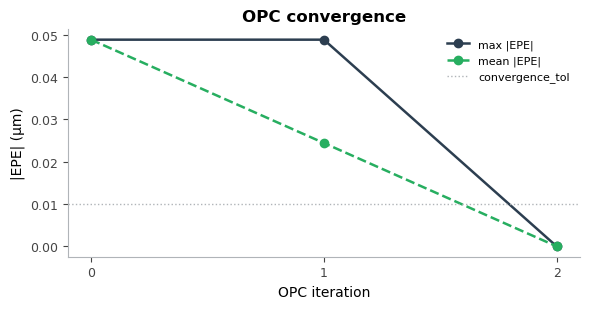

In [6]:
iterations = [h["iteration"] for h in result["history"]]
max_epe_series = [h["max_abs_epe"] for h in result["history"]]
mean_epe_series = [h["mean_abs_epe"] for h in result["history"]]

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(iterations, max_epe_series, "o-", color=MASK_COLOR, lw=1.8, label="max |EPE|")
ax.plot(iterations, mean_epe_series, "o--", color=IMAGE_COLOR, lw=1.8, label="mean |EPE|")
ax.axhline(0.01, color="#B0B4B8", ls=":", lw=1.0, label="convergence_tol")
ax.set_xlabel("OPC iteration")
ax.set_ylabel("|EPE| (µm)")
ax.set_xticks(iterations)
ax.set_title("OPC convergence", fontweight="bold")
ax.legend(loc="upper right", frameon=False, fontsize=8)
_style_ax(ax)
fig.tight_layout()
fig.savefig(ASSETS_DIR / "week12_opc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

- **Naive print** (uncorrected mask): the diffraction-limited system's own low-pass response
  widens the printed line relative to the target, giving a measurable EPE at both edges.
- **Edge-bias OPC** (`physics/opc.py::edge_bias_opc`) biases the mask edges inward, opposite the
  measured error, and re-checks the forward model each iteration -- purely by re-using
  `lens.py`/`imaging.py`'s existing forward chain and `imaging.edge_placement_error`'s existing
  metric, with no new forward physics.
- **Corrected print**: converges to a print that matches the target far more closely than the
  naive mask did, in a small number of iterations, for this well-behaved isolated-line case.

See `physics/opc.py`'s module docstring for the algorithm's Goodman 6.6.1 grounding and its one
documented limitation: this simple edge-bias approach is well-suited to isolated features like
the one above, but can fail to converge for densely-packed periodic patterns (nearest-edge
matching becomes ambiguous once edges shift close to a neighboring line) -- exactly the kind of
heuristic, iterative behavior real lithography OPC/resolution-enhancement techniques exhibit,
not a closed-form inverse of the imaging equation.